In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, log_loss, roc_auc_score,
                            confusion_matrix, roc_curve, classification_report,
                            f1_score, precision_score, recall_score, auc)

from myXGBoost.estimators.classifier import XGBClassifier as MyXGBClf

# Constants
N_CLASSES = 3
COLORS = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])

In [2]:
# Generate synthetic multiclass classification data
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    n_repeated=0,
    n_classes=N_CLASSES,
    n_clusters_per_class=1,
    random_state=42
)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Multiclass Classification Dataset Statistics:")
print("=" * 50)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Number of classes: {N_CLASSES}")
print(f"\nClass distribution (training):")
for i in range(N_CLASSES):
    count = np.sum(y_train == i)
    pct = np.mean(y_train == i) * 100
    print(f"  Class {i}: {count} samples ({pct:.1f}%)")

print(f"\nClass distribution (testing):")
for i in range(N_CLASSES):
    count = np.sum(y_test == i)
    pct = np.mean(y_test == i) * 100
    print(f"  Class {i}: {count} samples ({pct:.1f}%)")

Multiclass Classification Dataset Statistics:
X_train shape: (1600, 20)
X_test shape:  (400, 20)
y_train shape: (1600,)
y_test shape:  (400,)
Number of classes: 3

Class distribution (training):
  Class 0: 537 samples (33.6%)
  Class 1: 530 samples (33.1%)
  Class 2: 533 samples (33.3%)

Class distribution (testing):
  Class 0: 134 samples (33.5%)
  Class 1: 133 samples (33.2%)
  Class 2: 133 samples (33.2%)


In [3]:
# Create and train myXGBoost classifier
# using SoftmaxLoss (auto-selected for n_classes > 2)
clf = MyXGBClf(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)

t0 = time.time()
clf.fit(X_train, y_train)
t1 = time.time()
training_time = t1 - t0

# Make predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

print(f"myXGBoost Multiclass Training Complete!")
print("-" * 40)
print(f"Training time: {training_time:.4f} seconds")
print(f"Number of estimators: {clf.n_estimators}")
print(f"Detected classes: {clf.n_classes_}")
print(f"\nPredictions generated:")
print(f"  • Class predictions shape: {y_pred.shape}")
print(f"  • Probability predictions shape: {y_proba.shape}")

myXGBoost Multiclass Training Complete!
----------------------------------------
Training time: 4.7133 seconds
Number of estimators: 100
Detected classes: 3

Predictions generated:
  • Class predictions shape: (400,)
  • Probability predictions shape: (400, 3)


In [4]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_proba)

# Macro-averaged metrics
f1_macro = f1_score(y_test, y_pred, average='macro')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')

# ROC AUC (One-vs-Rest)
# Binarize labels for OVR calculation
y_test_bin = label_binarize(y_test, classes=range(N_CLASSES))
try:
    roc_auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr')
except Exception:
    roc_auc_ovr = float('nan')

print("myXGBoost Multiclass Results:")
print("=" * 60)
print(f"Primary Metrics:")
print(f"  • Accuracy:    {accuracy:.4f}")
print(f"  • Log Loss:    {logloss:.4f}")
print(f"  • ROC AUC (OvR): {roc_auc_ovr:.4f}")
print(f"  • F1 Score (Macro): {f1_macro:.4f}")
print(f"\nDetailed Metrics (Macro Average):")
print(f"  • Precision:   {precision_macro:.4f}")
print(f"  • Recall:      {recall_macro:.4f}")
print("=" * 60)

# Compare with baseline (majority class)
class_counts = [np.sum(y_test == i) for i in range(N_CLASSES)]
majority_class_idx = np.argmax(class_counts)
baseline_accuracy = class_counts[majority_class_idx] / len(y_test)
print(f"\nBaseline (majority class {majority_class_idx}): Accuracy = {baseline_accuracy:.4f}")
print(f"Improvement over baseline: {accuracy - baseline_accuracy:.4f} (+{(accuracy - baseline_accuracy) / baseline_accuracy * 100:.2f}%)")

# Generate detailed classification report
print("Classification Report:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=[f'Class {i}' for i in range(N_CLASSES)]))

myXGBoost Multiclass Results:
Primary Metrics:
  • Accuracy:    0.9550
  • Log Loss:    0.1651
  • ROC AUC (OvR): 0.9905
  • F1 Score (Macro): 0.9548

Detailed Metrics (Macro Average):
  • Precision:   0.9551
  • Recall:      0.9551

Baseline (majority class 0): Accuracy = 0.3350
Improvement over baseline: 0.6200 (+185.07%)
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.95      0.93      0.94       134
     Class 1       0.95      1.00      0.97       133
     Class 2       0.96      0.93      0.95       133

    accuracy                           0.95       400
   macro avg       0.96      0.96      0.95       400
weighted avg       0.96      0.95      0.95       400



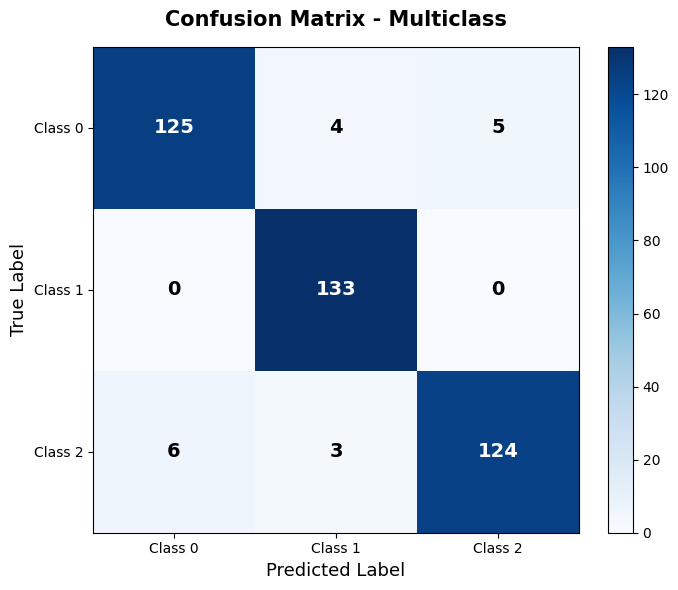

In [5]:
# Plotting - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, fraction=0.046, pad=0.04)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.title('Confusion Matrix - Multiclass', fontsize=15, pad=15, fontweight='bold')
plt.xticks(range(N_CLASSES), [f'Class {i}' for i in range(N_CLASSES)])
plt.yticks(range(N_CLASSES), [f'Class {i}' for i in range(N_CLASSES)])
plt.tight_layout()
plt.show()

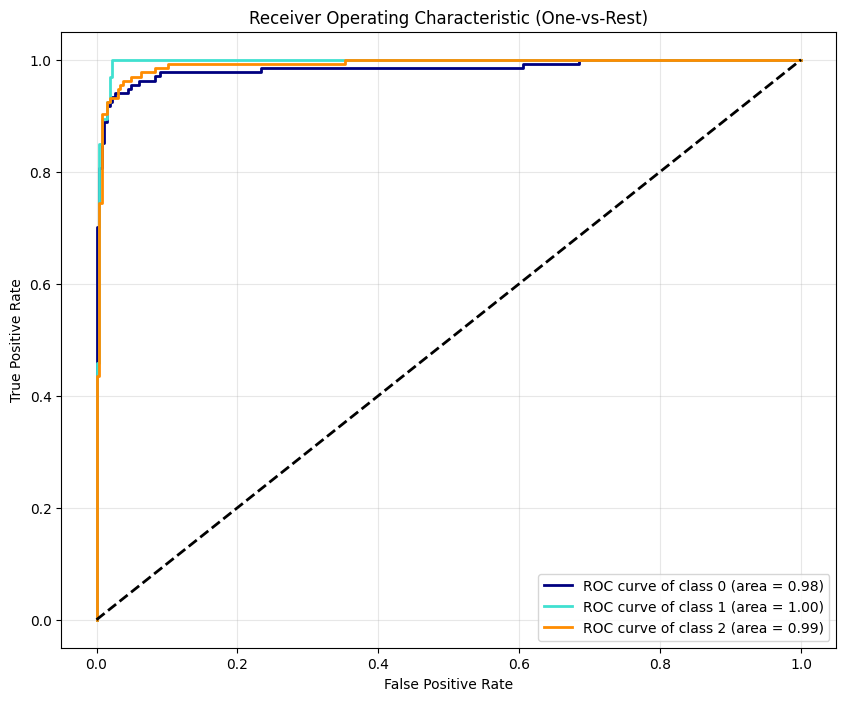

In [6]:
# ROC Curves (One-vs-Rest)
plt.figure(figsize=(10, 8))
for i, color in zip(range(N_CLASSES), COLORS):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

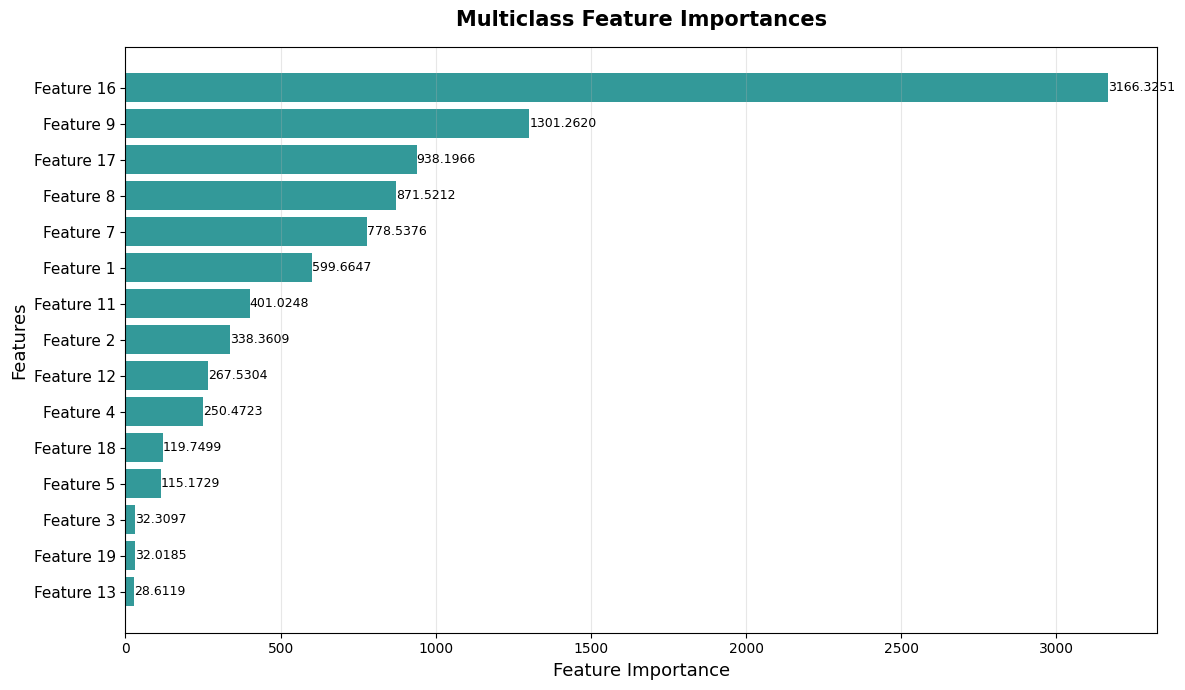


Top 15 Most Important Features:
--------------------------------------------------
 1. Feature 16      3166.325062 ( 33.9%)
 2. Feature 9       1301.262047 ( 13.9%)
 3. Feature 17      938.196568 ( 10.0%)
 4. Feature 8       871.521172 (  9.3%)
 5. Feature 7       778.537600 (  8.3%)
 6. Feature 1       599.664656 (  6.4%)
 7. Feature 11      401.024752 (  4.3%)
 8. Feature 2       338.360893 (  3.6%)
 9. Feature 12      267.530419 (  2.9%)
10. Feature 4       250.472312 (  2.7%)
11. Feature 18      119.749890 (  1.3%)
12. Feature 5       115.172862 (  1.2%)
13. Feature 3       32.309734 (  0.3%)
14. Feature 19      32.018534 (  0.3%)
15. Feature 13      28.611941 (  0.3%)


In [7]:
import math

# Feature Importance
importances = None
if hasattr(clf, 'feature_importances_'):
    try:
        importances = np.asarray(clf.feature_importances_)
    except Exception:
        importances = None

if importances is None and hasattr(clf, 'booster_'):
    try:
        from myXGBoost.utils.visualization import compute_feature_importance
        imp_dict = compute_feature_importance(clf.booster_, importance_type='gain')
        if imp_dict:
            n_feats = max(imp_dict.keys()) + 1
            importances = np.zeros(n_feats, dtype=float)
            for k, v in imp_dict.items():
                importances[k] = v
    except Exception as e:
        importances = None

if importances is not None and importances.size > 0 and not np.all(np.isnan(importances)):
    plt.figure(figsize=(12, 7))
    indices = np.argsort(importances)[::-1]
    sorted_importances = importances[indices]
    feature_names = [f'Feature {i+1}' for i in range(importances.size)]
    sorted_features = [feature_names[i] for i in indices]

    # Show top 15
    top_k = min(15, len(importances))
    
    bars = plt.barh(range(top_k), sorted_importances[:top_k], align='center', color='teal', alpha=0.8)
    
    for i, (bar, val) in enumerate(zip(bars, sorted_importances[:top_k])):
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

    plt.yticks(range(top_k), sorted_features[:top_k], fontsize=11)
    plt.xlabel('Feature Importance', fontsize=13)
    plt.ylabel('Features', fontsize=13)
    plt.title('Multiclass Feature Importances', fontsize=15, pad=15, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.gca().invert_yaxis() # Highest importance on top
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print("\nTop 15 Most Important Features:")
    print("-" * 50)
    total_imp = np.sum(importances)
    for i in range(top_k):
        feat_name = sorted_features[i]
        val = sorted_importances[i]
        pct = (val / total_imp * 100) if total_imp > 0 else 0
        print(f"{i+1:2d}. {feat_name:15} {val:.6f} ({pct:5.1f}%)")

else:
    print("Feature importances not available.")

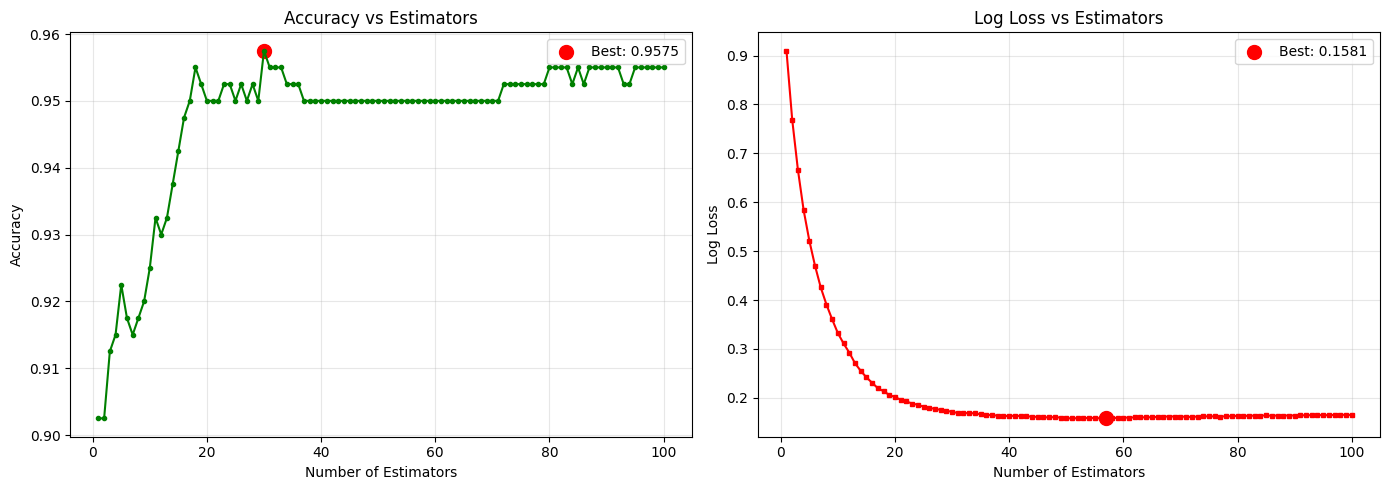

Learning Progress Summary:
----------------------------------------
Best Accuracy:  0.9575 at iteration 30
Best Log Loss:  0.1581 at iteration 57


In [8]:
# Learning Curves (Manual implementation for Multiclass)
# We need to manually reconstruct predictions at each stage for each class
staged_preds = None

if hasattr(clf, 'booster_'):
    try:
        booster = clf.booster_
        if hasattr(booster, 'trees_multiclass') and len(booster.trees_multiclass) == N_CLASSES:
            # Reconstruct staged predictions
            # trees_multiclass is List[List[DecisionTree]] where outer list is class, inner is iteration
            n_estimators_trained = len(booster.trees_multiclass[0])
            
            # Initial predictions: shape (n_classes,) -> broadcast to (n_samples, n_classes)
            initial_preds = getattr(booster, 'initial_predictions_multiclass', np.zeros(N_CLASSES))
            
            curr_preds = np.tile(initial_preds, (X_test.shape[0], 1))
            
            accuracy_scores = []
            logloss_scores = []
            from myXGBoost.loss.softmax_loss import softmax
            
            for i in range(n_estimators_trained):
                # Add contribution from tree i of each class
                for c in range(N_CLASSES):
                    if i < len(booster.trees_multiclass[c]):
                        tree = booster.trees_multiclass[c][i]
                        curr_preds[:, c] += booster.learning_rate * tree.predict(X_test)
                
                # Apply softmax
                stage_proba = softmax(curr_preds)
                stage_pred = np.argmax(stage_proba, axis=1)
                
                accuracy_scores.append(accuracy_score(y_test, stage_pred))
                logloss_scores.append(log_loss(y_test, stage_proba)) # log_loss handles multiclass probas
            
            # Plot
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Accuracy
            axes[0].plot(range(1, len(accuracy_scores) + 1), accuracy_scores, marker='o', markersize=3, linewidth=1.5, color='green')
            axes[0].set_xlabel('Number of Estimators')
            axes[0].set_ylabel('Accuracy')
            axes[0].set_title('Accuracy vs Estimators')
            axes[0].grid(True, alpha=0.3)
            
            best_acc_iter = int(np.argmax(accuracy_scores))
            axes[0].scatter(best_acc_iter + 1, accuracy_scores[best_acc_iter], color='red', s=100, label=f'Best: {accuracy_scores[best_acc_iter]:.4f}')
            axes[0].legend()

            # Log Loss
            axes[1].plot(range(1, len(logloss_scores) + 1), logloss_scores, marker='s', markersize=3, linewidth=1.5, color='red')
            axes[1].set_xlabel('Number of Estimators')
            axes[1].set_ylabel('Log Loss')
            axes[1].set_title('Log Loss vs Estimators')
            axes[1].grid(True, alpha=0.3)
            
            best_ll_iter = int(np.argmin(logloss_scores))
            axes[1].scatter(best_ll_iter + 1, logloss_scores[best_ll_iter], color='red', s=100, label=f'Best: {logloss_scores[best_ll_iter]:.4f}')
            axes[1].legend()
            
            plt.tight_layout()
            plt.show()

            print('Learning Progress Summary:')
            print('-' * 40)
            print(f"Best Accuracy:  {accuracy_scores[best_acc_iter]:.4f} at iteration {best_acc_iter + 1}")
            print(f"Best Log Loss:  {logloss_scores[best_ll_iter]:.4f} at iteration {best_ll_iter + 1}")
    except Exception as e:
        print(f"Could not generate learning curve: {e}")
        import traceback
        traceback.print_exc()